# Setup

In [1]:
# installs
!pip install nltk
!pip install tqdm

!pip install -U google-genai
!pip install -U langchain-google-genai google-generativeai

INFO: pip is looking at multiple versions of google-generativeai to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of google-generativeai to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.7 MB/s eta 0:00:00


In [2]:
# standard libraries
import os
import re
import string
import random
import warnings
import time
from math import nan
from operator import neg
from typing import List, Literal, Optional


# data handling libraries
import pandas as pd
import numpy as np

# Google libraries
from google.colab import drive, userdata
from google import genai
from google.genai import types
from google.genai.types import (
    FunctionDeclaration,
    GenerateContentConfig,
    GoogleSearch,
    HarmBlockThreshold,
    HarmCategory,
    MediaResolution,
    Part,
    Retrieval,
    SafetySetting,
    Tool,
    ToolCodeExecution,
    VertexAISearch,
)

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    RocCurveDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# utility libraries
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import HTML, Markdown, display
from pydantic import BaseModel, field_validator
from langchain.output_parsers import PydanticOutputParser

# mount google drive
drive.mount('/content/drive')

# define data path and change directory
mimic3_filespath = "/content/drive/MyDrive/mimic3_data"
os.chdir(mimic3_filespath)

Mounted at /content/drive


In [3]:
# Define constants & parameters
# if we have COLAB PRO and HIGH RAM RUNTIME, add these to the select drug names
# select_drug_names = ['Methylphenidate', 'Fentanyl', 'Insulin', 'Vicodin',
#                     'Ritalin', 'Concerta', 'Dextroamphetamine-amphetamine',
#                     'Adderall', 'Dextroamphetamine', 'Dexedrine', 'Codeine',
#                     'Morphine', 'Barbiturates', 'Alprazolam', 'Xanax',
#                     'Diazepam', 'Valium', 'Zolpidem', 'Ambien', 'Oxycodone',
#                     'OxyContin', 'Percocet', 'Hydrocodone', 'Norco']

# make the drug names lower case
select_drug_uom = 'mcg'
select_drug_names = ['Fentanyl']
select_drug_names_lower = [x.lower() for x in select_drug_names]
print(select_drug_names_lower)
print(select_drug_uom)

select_notes_categories = ['Consult', 'Physician', 'General', 'Nursing', 'Nursing/other', 'Pharmacy']
select_notes_categories_lower = [x.lower() for x in select_notes_categories]
print(select_notes_categories_lower)

events_db_carevue = 'inputevents_cv'
events_db_metavision = 'inputevents_mv'
events_db_chart = 'chartevents'
events_db_all = [events_db_carevue, events_db_metavision, events_db_chart]
print(events_db_all)

mv_db = 'metavision'
cv_db = 'carevue'
hosp_db = 'hospital'
db_all = [mv_db, cv_db, hosp_db]
print(db_all)

['fentanyl']
mcg
['consult', 'physician', 'general', 'nursing', 'nursing/other', 'pharmacy']
['inputevents_cv', 'inputevents_mv', 'chartevents']
['metavision', 'carevue', 'hospital']


In [4]:
# get Google API key from environment variables
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")

# initialize Google AI client
google_ai_client = genai.Client(api_key=GOOGLE_API_KEY)

# Data Processing

## Data Loading and Initial Cleaning

In [26]:
# Load patients data
patients_df = pd.read_csv('PATIENTS.csv.gz').set_index('ROW_ID')
print(f'Patients Table Size: {len(patients_df)}')

# Load admissions data
admissions_df = pd.read_csv('ADMISSIONS.csv.gz').set_index('ROW_ID')
print(f'Admissions Table Size: {len(admissions_df)}')

Patients Table Size: 46520
Admissions Table Size: 58976


In [27]:
# Load d_items data
d_items_df = pd.read_csv('D_ITEMS.csv.gz').set_index('ROW_ID')
print(f'D_Items Table Size: {len(d_items_df)}')

D_Items Table Size: 12487


In [28]:
# filter d_items data for our select drug & data sources
select_drug_items_df = d_items_df[
    (d_items_df['LABEL'].str.lower().str.contains('|'.join(select_drug_names_lower))) &  # Join drug names with '|' for regex 'or'
    (d_items_df['LINKSTO'].isin([events_db_carevue, events_db_metavision])) &
    (d_items_df['DBSOURCE'].isin([mv_db, cv_db]))
]
print(f'Select Drug Items Table Size: {len(select_drug_items_df)}')
print(f'Select Drug Items Table Size: {select_drug_items_df.shape}')

Select Drug Items Table Size: 8
Select Drug Items Table Size: (8, 9)


In [29]:
# Load inputevents_mv (metavision) data
inputevents_mv_df = pd.read_csv('INPUTEVENTS_MV.csv.gz', low_memory=False).set_index('ROW_ID')
print(f'InputEvents_MV Table Size: {len(inputevents_mv_df)}')

InputEvents_MV Table Size: 3618991


In [30]:
# filter inputevents_mv data by select drug Items and Amount > 0 and AmountUOM is not null
select_drug_mv_df = inputevents_mv_df[inputevents_mv_df['ITEMID'].isin(select_drug_items_df.ITEMID) & (inputevents_mv_df['AMOUNT'] > 0) & (inputevents_mv_df['AMOUNTUOM'].notnull())]

# drop columns that are not needed
select_drug_mv_df = select_drug_mv_df.drop(columns=['RATE', 'RATEUOM', 'STORETIME', 'ORDERID', 'LINKORDERID', 'ORDERCATEGORYNAME', 'SECONDARYORDERCATEGORYNAME', 'ORDERCOMPONENTTYPEDESCRIPTION', 'ORDERCATEGORYDESCRIPTION', 'PATIENTWEIGHT', 'TOTALAMOUNT', 'TOTALAMOUNTUOM', 'ISOPENBAG', 'CONTINUEINNEXTDEPT', 'CANCELREASON', 'STATUSDESCRIPTION', 'COMMENTS_EDITEDBY', 'COMMENTS_CANCELEDBY', 'COMMENTS_DATE', 'ORIGINALAMOUNT', 'ORIGINALRATE'])

print(f'Select Drug InputEvents_MV Table Size: {len(select_drug_mv_df)}')
print(f'Select Drug InputEvents_MV Table Size: {select_drug_mv_df.shape}')
print(list(select_drug_mv_df))

Select Drug InputEvents_MV Table Size: 131846
Select Drug InputEvents_MV Table Size: (131846, 9)
['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'STARTTIME', 'ENDTIME', 'ITEMID', 'AMOUNT', 'AMOUNTUOM', 'CGID']


In [31]:
# Load inputevents_cv (carevue) data
inputevents_cv_df = pd.read_csv('INPUTEVENTS_CV.csv.gz', low_memory=False).set_index('ROW_ID')
print(f'InputEvents_CV Table Size: {len(inputevents_cv_df)}')

InputEvents_CV Table Size: 17527935


In [32]:
# filter inputevents_cv data by select drug Items and Amount > 0 and AmountUOM is not null
select_drug_cv_df = inputevents_cv_df[inputevents_cv_df['ITEMID'].isin(select_drug_items_df.ITEMID) & (inputevents_cv_df['AMOUNT'] > 0) & (inputevents_cv_df['AMOUNTUOM'].notnull())]

# drop columns that are not needed
select_drug_cv_df = select_drug_cv_df.drop(columns=['RATE', 'RATEUOM', 'STORETIME', 'ORDERID', 'LINKORDERID', 'STOPPED', 'NEWBOTTLE', 'ORIGINALAMOUNT', 'ORIGINALAMOUNTUOM', 'ORIGINALROUTE', 'ORIGINALRATE', 'ORIGINALRATEUOM', 'ORIGINALSITE'])

print(f'Select Drug InputEvents_CV Table Size: {len(select_drug_cv_df)}')
print(f'Select Drug InputEvents_CV Table Size: {select_drug_cv_df.shape}')
print(list(select_drug_cv_df))

Select Drug InputEvents_CV Table Size: 370535
Select Drug InputEvents_CV Table Size: (370535, 8)
['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'CHARTTIME', 'ITEMID', 'AMOUNT', 'AMOUNTUOM', 'CGID']


In [33]:
# combine select_drug_cv_df (carevue) and select_drug_mv_df (metavision) into one dataframe
select_drug_ie_df = pd.concat([select_drug_cv_df, select_drug_mv_df])
print(f'Select Drug InputEvents Table Size: {len(select_drug_ie_df)}')
print(f'Select Drug InputEvents Table Size: {select_drug_ie_df.shape}')
print(list(select_drug_ie_df))

Select Drug InputEvents Table Size: 502381
Select Drug InputEvents Table Size: (502381, 10)
['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'CHARTTIME', 'ITEMID', 'AMOUNT', 'AMOUNTUOM', 'CGID', 'STARTTIME', 'ENDTIME']


In [34]:
# Load NoteEvents data
noteevents_df = pd.read_csv('NOTEEVENTS.csv.gz', low_memory=False).set_index('ROW_ID')
print(f'NoteEvents Table Size: {len(noteevents_df)}')

NoteEvents Table Size: 2083180


In [35]:
# filter noteevents for select categories & drug names
selected_notes_df = noteevents_df[noteevents_df['CATEGORY'].str.lower().str.contains('|'.join(select_notes_categories_lower))]
print(f'Selected Notes Table Size: {len(selected_notes_df)}')

selected_notes_df = selected_notes_df[selected_notes_df['TEXT'].str.lower().str.contains('|'.join(select_drug_names_lower))]
print(f'Selected Notes Table Size: {len(selected_notes_df)}')

Selected Notes Table Size: 1196179
Selected Notes Table Size: 113960


## Text Cleaning and Preprocessing

In [36]:
# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

#define the function to clean the text from stopwords, punctuations, whitespaces, etc
def clean_text(text, remove_stopwords=True, stemming=False, lemmatization=False, remove_numbers=False):
    """
    Clean and preprocess text data for AI applications

    Parameters:
    -----------
    text : str
        The input text to clean
    remove_stopwords : bool
        Whether to remove stopwords
    stemming : bool
        Whether to apply stemming
    lemmatization : bool
        Whether to apply lemmatization

    Returns:
    --------
    str
        Cleaned text
    """

    # Custom Punctuation String
    cust_punctuation_str = '!"#$%&\'()*+,.:;<=>?@[\\]^_`{|}~'

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', cust_punctuation_str))

    # Remove numbers (optional)
    if remove_numbers:
      text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = text.split()

    # Remove stopwords
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [token for token in tokens if token not in stop_words]

    # Apply stemming
    if stemming:
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(token) for token in tokens]

    # Apply lemmatization
    if lemmatization:
       lemmatizer = WordNetLemmatizer()
       tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Join tokens back into text
    cleaned_text = ' '.join(tokens)

    return cleaned_text

# Example usage
sample_text = "Hello! This is an example text with numbers (123) and mcg/hr, 200-250 mcg/hr punctuation. https://example.com"
cleaned_text = clean_text(sample_text, remove_stopwords=True)
print(cleaned_text)

hello example text numbers 123 mcg/hr 200-250 mcg/hr punctuation


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [37]:
# define a function to find the selected drug name as "str1", dosage UOM as "str2" (or vice-versa)
# from the main clinical notes as "text" within the proximity of 100 chars as default value
def find_all_proximity_text_optimized(text, str1, str2, proximity=100):
    # convert input text to lower
    in_text = text.lower()

    # Use regex for efficient searching
    positions1 = [match.start() for match in re.finditer(re.escape(str1), in_text)]
    positions2 = [match.start() for match in re.finditer(re.escape(str2), in_text)]

    # Convert lists to sets for faster lookup
    positions2_set = set(positions2)

    matched_substrings = []

    # Efficiently check for proximity using sorted positions
    for pos1 in positions1:
        # Find nearest positions of str2
        close_positions = [pos2 for pos2 in positions2_set if abs(pos1 - pos2) <= proximity]
        if close_positions:
            start_index = max(0, min(pos1, min(close_positions)) - proximity)
            end_index = min(len(text), max(pos1, max(close_positions)) + proximity)
            matched_substrings.append(text[start_index:end_index])

    return matched_substrings if matched_substrings else None

# Example usage
text = "In this long document,propofol 100mcg appears first, and is not followed by next 'n' number of characters i.e. 'fentanyl' for a long time and then much later, it appears within the allowed proximity. i.e. fentanyl 100mcg comes again after many many characters comes fentanyl 200mcg."
str2 = "fentanyl"
str1 = "mcg"
proximity = 25

result = find_all_proximity_text_optimized(clean_text(text, remove_stopwords=True), str1, str2, proximity)
if result:
    for match in result:
        print(f'Matching text: "{match}"')
else:
    print(f'"{str1}" and "{str2}" are NOT within {proximity} characters of each other.')

Matching text: "hin allowed proximity ie fentanyl 100mcg comes many many chara"
Matching text: "ny many characters comes fentanyl 200mcg"


In [38]:
# add/update matching_text from main clinical notes TEXT with the drugname and its UOM within proximity of each other and extract 25 chars before & after the absolute positions
selected_notes_df['MATCHING_TEXT'] = selected_notes_df.apply(lambda row: find_all_proximity_text_optimized(
    clean_text(row['TEXT'], remove_stopwords=True),
    select_drug_uom,
    select_drug_names_lower[0], 25), axis=1)

print(selected_notes_df.shape)
print(len(selected_notes_df))

(113960, 11)
113960


In [39]:
print(len(select_drug_mv_df))
print(len(selected_notes_df))

131846
113960


In [ ]:
# filter selected_notes_df where SUBJECT_ID = 67906 and HADM_ID = 122154
selected_notes_df1 = selected_notes_df[(selected_notes_df.SUBJECT_ID == 67906) & (selected_notes_df.HADM_ID == 122154)]
print(selected_notes_df1.shape)
print(len(selected_notes_df1))

# print selected_notes_df1['MATCHING_TEXT'] for first 20 records
for index, row in selected_notes_df1.iterrows():
  print(f"PatientID: {row.SUBJECT_ID}, AdmissionID: {row.HADM_ID}")
  # iterate thru the list and print all items in MATCHING_TEXT list
  # Check if MATCHING_TEXT is a list before iterating
  if row.MATCHING_TEXT is not None and isinstance(row.MATCHING_TEXT, list):
    idx=0
    for item in row.MATCHING_TEXT:
      print(f"MATCHING_TEXT[{idx}]: {item}")
      idx=idx+1
  else:
    print(f"MATCHING_TEXT is empty or is not a list for this row: {row.MATCHING_TEXT}, {row.MATCHING_TEXT}")
  print(f"ORIGINAL_TEXT: {row.TEXT}")

(396, 11)
396
PatientID: 67906, AdmissionID: 122154.0
MATCHING_TEXT[0]:  2178-8-5 0600 infusions fentanyl - 75 mcg/hour midazolam versed
ORIGINAL_TEXT: Chief Complaint:
   24 Hour Events:
   Went up on his sedation, as pt slightly more agitated and
   dys-synchronous on vent
   Allergies:
   No Known Drug Allergies
   Last dose of Antibiotics:
   Vancomycin - [**2178-8-5**] 06:00 AM
   Infusions:
   Fentanyl - 75 mcg/hour
   Midazolam (Versed) - 5 mg/hour
   Heparin Sodium - 1,550 units/hour
   Other ICU medications:
   Fentanyl - [**2178-8-6**] 10:00 PM
   Midazolam (Versed) - [**2178-8-6**] 10:00 PM
   Other medications:
   Changes to medical and family history:
   Review of systems is unchanged from admission except as noted below
   Review of systems:
   Flowsheet Data as of  [**2178-8-7**] 04:06 AM
   Vital signs
   Hemodynamic monitoring
   Fluid balance
                                                                  24 hours
                                                    

In [ ]:
#selected_notes_df1.head(20)

,SUBJECT_ID,HADM_ID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,CGID,ISERROR,TEXT,MATCHING_TEXT
ROW_ID,,,,,,,,,,,
583632,67906,122154.0,2178-08-07,2178-08-07 04:06:00,2178-08-07 09:39:26,Physician,Physician Resident Progress Note,16553.0,NaN,Chief Complaint:\n 24 Hour Events:\n Went ...,[ 2178-8-5 0600 infusions fentanyl - 75 mcg/ho...
583781,67906,122154.0,2178-08-08,2178-08-08 06:13:00,2178-08-08 06:50:37,Physician,Physician Resident Progress Note,16553.0,NaN,Chief Complaint:\n 24 Hour Events:\n SPUTUM ...,[ 2178-8-8 0400 infusions fentanyl - 75 mcg/ho...
583945,67906,122154.0,2178-08-09,2178-08-09 06:12:00,2178-08-09 06:12:15,Physician,Physician Resident Progress Note,15127.0,NaN,Chief Complaint:\n 24 Hour Events:\n - abd...,[zolam versed - 6 mg/hour fentanyl - 100 mcg/h...
583947,67906,122154.0,2178-08-09,2178-08-09 06:12:00,2178-08-09 06:19:16,Physician,Physician Resident Progress Note,15127.0,NaN,Chief Complaint:\n 24 Hour Events:\n - abd...,[zolam versed - 6 mg/hour fentanyl - 100 mcg/h...
583948,67906,122154.0,2178-08-09,2178-08-09 06:12:00,2178-08-09 06:20:30,Physician,Physician Resident Progress Note,15127.0,NaN,Chief Complaint:\n 24 Hour Events:\n - abd...,[zolam versed - 6 mg/hour fentanyl - 100 mcg/h...
583949,67906,122154.0,2178-08-09,2178-08-09 06:12:00,2178-08-09 06:22:31,Physician,Physician Resident Progress Note,15127.0,NaN,Chief Complaint:\n 24 Hour Events:\n - abd...,[zolam versed - 6 mg/hour fentanyl - 100 mcg/h...
583637,67906,122154.0,2178-08-07,2178-08-07 04:06:00,2178-08-07 10:11:19,Physician,Physician Resident Progress Note,16553.0,NaN,Chief Complaint:\n 24 Hour Events:\n Went ...,[ 2178-8-5 0600 infusions fentanyl - 75 mcg/ho...
583638,67906,122154.0,2178-08-07,2178-08-07 04:06:00,2178-08-07 10:18:29,Physician,Physician Resident Progress Note,16553.0,NaN,Chief Complaint:\n 24 Hour Events:\n Went ...,[ 2178-8-5 0600 infusions fentanyl - 75 mcg/ho...
583766,67906,122154.0,2178-08-08,2178-08-08 06:13:00,2178-08-08 06:13:29,Physician,Physician Resident Progress Note,16553.0,NaN,Chief Complaint:\n 24 Hour Events:\n SPUTUM ...,[ 2178-8-8 0400 infusions fentanyl - 75 mcg/ho...


In [ ]:
# checking the data for a single patient/admission ID combination
# filter metavision data form select_drug_mv_df for SUBJECT_ID = 67906 and HADM_ID = 122154
select_drug_mv_df1 = select_drug_mv_df[(select_drug_mv_df.SUBJECT_ID == 67906) & (select_drug_mv_df.HADM_ID == 122154)]

print(select_drug_mv_df1.shape)
print(len(select_drug_mv_df1))
select_drug_mv_df1.head(20)

(265, 9)
265


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,STARTTIME,ENDTIME,ITEMID,AMOUNT,AMOUNTUOM,CGID
ROW_ID,,,,,,,,,
803110,67906,122154,207346.0,2178-09-02 21:46:00,2178-09-02 21:47:00,221744,99.999997,mcg,14949
803424,67906,122154,207346.0,2178-08-22 22:35:00,2178-08-22 22:36:00,221744,99.999997,mcg,20214
803429,67906,122154,207346.0,2178-08-06 22:21:00,2178-08-07 11:38:00,221744,1.012358,mg,16707
803431,67906,122154,207346.0,2178-09-05 04:00:00,2178-09-05 04:01:00,221744,149.999990,mcg,19838
803432,67906,122154,207346.0,2178-08-15 05:01:00,2178-08-15 14:24:00,221744,1.193992,mg,15407
801829,67906,122154,207346.0,2178-09-06 05:00:00,2178-09-06 05:10:00,221744,0.028000,mg,20214
800587,67906,122154,207346.0,2178-08-09 19:31:00,2178-08-10 14:45:00,221744,2.447422,mg,17574
802603,67906,122154,207346.0,2178-09-08 09:51:00,2178-09-08 09:52:00,221744,99.999997,mcg,20115
802917,67906,122154,207346.0,2178-08-09 19:31:00,2178-08-09 19:32:00,221744,0.002121,mg,17574


In [40]:
# merge selected_notes_df and select_drug_mv_df on SUBJECT_ID, HADM_ID and CGID
merged_df1 = pd.merge(select_drug_mv_df, selected_notes_df, on=['SUBJECT_ID', 'HADM_ID', 'CGID'], how='inner')

# make sure that the merged_df1.charttime is in between select_drug_mv_df.starttime and select_drug_mv_df.endtime
merged_df1 = merged_df1[merged_df1['CHARTTIME'].between(merged_df1['STARTTIME'], merged_df1['ENDTIME'])]

print(merged_df1.shape)
print(len(merged_df1))
merged_df1.head(20)
# merged_df.to_csv('selected_drugnotes_df.csv', index=False)

(15306, 17)
15306


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,STARTTIME,ENDTIME,ITEMID,AMOUNT,AMOUNTUOM,CGID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,ISERROR,TEXT,MATCHING_TEXT
3,30354,120396,243526.0,2154-12-24 12:41:00,2154-12-28 16:41:00,221744,2.500000,mg,19348,2154-12-24,2154-12-24 18:30:00,2154-12-24 18:32:30,Nursing,Nursing Progress Note,NaN,"Renal failure, acute (Acute renal failure, ARF...",None
4,30354,120396,243526.0,2154-12-24 12:41:00,2154-12-28 16:41:00,221744,2.500000,mg,19348,2154-12-24,2154-12-24 17:22:00,2154-12-24 18:26:57,Nursing,Nursing Progress Note,NaN,"Renal failure, acute (Acute renal failure, ARF...",None
5,30354,120396,243526.0,2154-12-24 12:41:00,2154-12-28 16:41:00,221744,2.500000,mg,19348,2154-12-24,2154-12-24 17:22:00,2154-12-24 17:22:04,Nursing,Nursing Progress Note,NaN,"Renal failure, acute (Acute renal failure, ARF...",None
9,30354,120396,243526.0,2154-12-24 15:35:00,2154-12-25 05:01:00,221744,0.671780,mg,19348,2154-12-24,2154-12-24 18:30:00,2154-12-24 18:32:30,Nursing,Nursing Progress Note,NaN,"Renal failure, acute (Acute renal failure, ARF...",None
10,30354,120396,243526.0,2154-12-24 15:35:00,2154-12-25 05:01:00,221744,0.671780,mg,19348,2154-12-24,2154-12-24 17:22:00,2154-12-24 18:26:57,Nursing,Nursing Progress Note,NaN,"Renal failure, acute (Acute renal failure, ARF...",None
11,30354,120396,243526.0,2154-12-24 15:35:00,2154-12-25 05:01:00,221744,0.671780,mg,19348,2154-12-24,2154-12-24 17:22:00,2154-12-24 17:22:04,Nursing,Nursing Progress Note,NaN,"Renal failure, acute (Acute renal failure, ARF...",None
12,30354,120396,243526.0,2154-12-24 12:00:00,2154-12-28 16:00:00,221744,2.500000,mg,19348,2154-12-24,2154-12-24 18:30:00,2154-12-24 18:32:30,Nursing,Nursing Progress Note,NaN,"Renal failure, acute (Acute renal failure, ARF...",None
13,30354,120396,243526.0,2154-12-24 12:00:00,2154-12-28 16:00:00,221744,2.500000,mg,19348,2154-12-24,2154-12-24 17:22:00,2154-12-24 18:26:57,Nursing,Nursing Progress Note,NaN,"Renal failure, acute (Acute renal failure, ARF...",None
14,30354,120396,243526.0,2154-12-24 12:00:00,2154-12-28 16:00:00,221744,2.500000,mg,19348,2154-12-24,2154-12-24 17:22:00,2154-12-24 17:22:04,Nursing,Nursing Progress Note,NaN,"Renal failure, acute (Acute renal failure, ARF...",None
21,30354,120396,243526.0,2154-12-24 12:41:00,2154-12-28 16:41:00,221744,2.500000,mg,19348,2154-12-24,2154-12-24 18:30:00,2154-12-24 18:32:30,Nursing,Nursing Progress Note,NaN,"Renal failure, acute (Acute renal failure, ARF...",None


In [41]:
# filter merged_df1 by SUBJECT_ID = 67906 and HADM_ID = 122154 (this was for manual testing of data)
merged_df1_mv = merged_df1[(merged_df1.SUBJECT_ID == 67906) & (merged_df1.HADM_ID == 122154)]

print(merged_df1_mv.shape)
print(len(merged_df1_mv))
merged_df1_mv.head(20)

(134, 17)
134


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,STARTTIME,ENDTIME,ITEMID,AMOUNT,AMOUNTUOM,CGID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,ISERROR,TEXT,MATCHING_TEXT
81246,67906,122154,207346.0,2178-08-13 08:22:00,2178-08-14 00:44:00,221744,2.500000,mg,16643,2178-08-13,2178-08-13 15:50:00,2178-08-13 15:50:43,Nursing,Nursing Progress Note,NaN,51 yr old man admitted on [**7-28**] with COP...,None
81247,67906,122154,207346.0,2178-08-13 08:22:00,2178-08-14 00:44:00,221744,2.500000,mg,16643,2178-08-13,2178-08-13 15:50:00,2178-08-13 19:02:35,Nursing,Nursing Progress Note,NaN,51 yr old man admitted on [**7-28**] with COP...,None
81248,67906,122154,207346.0,2178-08-13 08:22:00,2178-08-14 00:44:00,221744,2.500000,mg,16643,2178-08-13,2178-08-13 15:50:00,2178-08-13 18:08:10,Nursing,Nursing Progress Note,NaN,51 yr old man admitted on [**7-28**] with COP...,None
81249,67906,122154,207346.0,2178-08-13 08:22:00,2178-08-14 00:44:00,221744,2.500000,mg,16643,2178-08-13,2178-08-13 15:50:00,2178-08-13 18:13:06,Nursing,Nursing Progress Note,NaN,51 yr old man admitted on [**7-28**] with COP...,None
81330,67906,122154,207346.0,2178-08-02 14:57:00,2178-08-03 14:14:00,221744,1.892000,mg,19689,2178-08-02,2178-08-02 15:38:00,2178-08-02 15:38:57,Nursing,Nursing Progress Note,NaN,TITLE: 51 yr old man with COPD (followed by D ...,None
81498,67906,122154,207346.0,2178-08-03 15:00:00,2178-08-03 17:30:00,221744,0.316337,mg,14214,2178-08-03,2178-08-03 15:12:00,2178-08-03 15:46:49,Nursing,Nursing Progress Note,NaN,51 y/o M with a history of severe mixed obstru...,None
81499,67906,122154,207346.0,2178-08-03 15:00:00,2178-08-03 17:30:00,221744,0.316337,mg,14214,2178-08-03,2178-08-03 15:12:00,2178-08-03 15:50:06,Nursing,Nursing Progress Note,NaN,51 y/o M with a history of severe mixed obstru...,None
81500,67906,122154,207346.0,2178-08-03 15:00:00,2178-08-03 17:30:00,221744,0.316337,mg,14214,2178-08-03,2178-08-03 15:12:00,2178-08-03 15:54:58,Nursing,Nursing Progress Note,NaN,51 y/o M with a history of severe mixed obstru...,None
81501,67906,122154,207346.0,2178-08-03 15:00:00,2178-08-03 17:30:00,221744,0.316337,mg,14214,2178-08-03,2178-08-03 15:12:00,2178-08-03 15:25:45,Nursing,Nursing Progress Note,NaN,51 y/o M with a history of severe mixed obstru...,None
81502,67906,122154,207346.0,2178-08-03 15:00:00,2178-08-03 17:30:00,221744,0.316337,mg,14214,2178-08-03,2178-08-03 15:12:00,2178-08-03 15:36:40,Nursing,Nursing Progress Note,NaN,51 y/o M with a history of severe mixed obstru...,None


# Zero-Shot Learning
Gemini 2.0 Flash Model

In [42]:
# define a function to extract drug dosage information from clinical notes using Google's Gemini API
def call_llm_api(drugname, clinical_notes, model_name="gemini-2.0-flash"):
  if clinical_notes is None:
    return None

  role = 'You are a medical professional/expert or a nurse practitioner or a Physician'

  prompt = f"""Can you just extract the dosage for {drugname} from the following clinical notes texts {clinical_notes} and if there are more than one dosages specified, pick the one that is most relevant? Please don't provide any medical advice, just give me a short response in the format of ' mcg'"""

  response = google_ai_client.models.generate_content(
      model=model_name,
      contents=prompt,
      config=types.GenerateContentConfig(
        system_instruction=role,
        max_output_tokens= 400,
        #top_k= 2,
        #top_p= 0.5,
        temperature= 0.5,
        stop_sequences= ['\n'],
        seed=42,
      ),
  )

  return (response.text)

In [43]:
#define clinical notes for testing the LLM API
clinical_notes = "remain absent/impaired pt fentanyl 100mcg/hr versed 6mg/hr spon, overnight sedation weaned fentanyl 75mcg/hr versed 4mg/hr resp"

# call the LLM API specifying a particular drugname & a portion of clinical notes
call_llm_api(select_drug_names_lower[0], clinical_notes)

'75 mcg'

In [44]:
# Example to test the LLM response using Gemini AI API and "gemini-2.0-flash" model
response = google_ai_client.models.generate_content(
    model="gemini-2.0-flash",
    contents=f"""As a medical professional or a nurse practitioner or physician, can you extract the {select_drug_names_lower} latest/primary dosage amount from the following clinical notes texts {clinical_notes}?"""
)
print(response.text)

Based on the clinical notes provided, the latest/primary fentanyl dosage is **75 mcg/hr**.



In [45]:
# define function that calculates the dosage as per UOM, inputs were from inputevents_mv:
def get_ie_dosage(amount: float, uom: str) -> str:
    if uom.lower() == 'mcg':
        return f"{amount} mcg"
    elif uom.lower() == 'mg':
        converted_amount = amount * 1000
        return f"{converted_amount} mcg"
    else:
        return "Invalid unit of measurement"

# Example usage:
dosage = get_ie_dosage(0.15, 'mg')
print(dosage)  # Output: 1500.0 mcg

dosage = get_ie_dosage(250.0, 'mcg')
print(dosage)  # Output: 2.0 mcg

150.0 mcg
250.0 mcg


In [46]:
# old function to split dosage string/LLM response between dosage & it's UOM (this was prior to using Pydantic & Langchain)
def split_dosage_string(dosage_string):
    """
    Splits a dosage string into a float value and a unit of measurement (UOM),
    handling both spaced and non-spaced formats (e.g., "100mcg" and "100 mcg").

    Args:
        dosage_string (str): Dosage string like "100mcg" or "100 mcg".

    Returns:
        tuple: (dosage as float, UOM as string).
    """
    try:
        # Use regular expression to separate the numeric part and the unit
        match = re.match(r"(\d*\.?\d+)\s*(\D+)", dosage_string)
        if match:
            dosage = float(match.group(1))  # Extract numeric part and convert to float
            uom = match.group(2).lower()   # Extract unit and convert to lowercase
            return dosage, uom
        else:
            raise ValueError(f"Invalid format: {dosage_string}")
    except ValueError as e:
        print(e)
        pass
        #return None

# Example usage
examples = ["100mcg", "100 mcg", "15mg", "1.33 mg", "1200mcg", "1.24mg"]
for example in examples:
    result = split_dosage_string(example)
    print(f"Input: {example} -> Output: {result}")

Input: 100mcg -> Output: (100.0, 'mcg')
Input: 100 mcg -> Output: (100.0, 'mcg')
Input: 15mg -> Output: (15.0, 'mg')
Input: 1.33 mg -> Output: (1.33, 'mg')
Input: 1200mcg -> Output: (1200.0, 'mcg')
Input: 1.24mg -> Output: (1.24, 'mg')


In [47]:
#old section to get LLM response, get dosage from input event, and eva;uate the MATCH result, do not use again
print(list(merged_df1_mv))
print(merged_df1_mv.shape)

merged_df1_mv.loc[:, 'DOSAGE_FROM_TEXT'] = merged_df1_mv.apply(lambda row: call_llm_api(select_drug_names_lower[0], row.MATCHING_TEXT), axis=1)

merged_df1_mv.loc[:, 'DOSAGE_FROM_IE'] = merged_df1_mv.apply(lambda row: get_ie_dosage(row.AMOUNT, row.AMOUNTUOM), axis=1)

# Compare element-wise and assign True/False to DOSAGE_MATCH column
merged_df1_mv.loc[:, 'DOSAGE_MATCH'] = merged_df1_mv['DOSAGE_FROM_TEXT'] == merged_df1_mv['DOSAGE_FROM_IE']

print(merged_df1_mv.shape)
print(len(merged_df1_mv))
print(merged_df1_mv.head(20))

['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'STARTTIME', 'ENDTIME', 'ITEMID', 'AMOUNT', 'AMOUNTUOM', 'CGID', 'CHARTDATE', 'CHARTTIME', 'STORETIME', 'CATEGORY', 'DESCRIPTION', 'ISERROR', 'TEXT', 'MATCHING_TEXT']
(134, 17)
(134, 20)
134
       SUBJECT_ID  HADM_ID  ICUSTAY_ID            STARTTIME  \
81246       67906   122154    207346.0  2178-08-13 08:22:00   
81247       67906   122154    207346.0  2178-08-13 08:22:00   
81248       67906   122154    207346.0  2178-08-13 08:22:00   
81249       67906   122154    207346.0  2178-08-13 08:22:00   
81330       67906   122154    207346.0  2178-08-02 14:57:00   
81498       67906   122154    207346.0  2178-08-03 15:00:00   
81499       67906   122154    207346.0  2178-08-03 15:00:00   
81500       67906   122154    207346.0  2178-08-03 15:00:00   
81501       67906   122154    207346.0  2178-08-03 15:00:00   
81502       67906   122154    207346.0  2178-08-03 15:00:00   
81503       67906   122154    207346.0  2178-08-03 15:00:00   
81504       6

<ipython-input-47-6de16ebf0c1b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df1_mv.loc[:, 'DOSAGE_FROM_TEXT'] = merged_df1_mv.apply(lambda row: call_llm_api(select_drug_names_lower[0], row.MATCHING_TEXT), axis=1)
<ipython-input-47-6de16ebf0c1b>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df1_mv.loc[:, 'DOSAGE_FROM_IE'] = merged_df1_mv.apply(lambda row: get_ie_dosage(row.AMOUNT, row.AMOUNTUOM), axis=1)
<ipython-input-47-6de16ebf0c1b>:10: SettingWithCopyWarning: 
A value is trying to b

In [ ]:
# old section to print some outputs/recent updates to the dataframe, do not use again
for index, row in merged_df1_mv.iterrows():
  print(f"PatientID: {row.SUBJECT_ID}, AdmissionID: {row.HADM_ID}")
  #iterate thru the list and print all items in MATCHING_TEXT list
  # Check if MATCHING_TEXT is a list before iterating
  if row.MATCHING_TEXT is not None and isinstance(row.MATCHING_TEXT, list):
    idx=0
    for item in row.MATCHING_TEXT:
      print(f"MATCHING_TEXT[{idx}]: {item}")
      idx=idx+1
  else:
    print(f"MATCHING_TEXT is empty or is not a list for this row: {row.MATCHING_TEXT}, {row.MATCHING_TEXT}")
  #print(f"ORIGINAL_TEXT: {row.TEXT}")

  if row.DOSAGE_FROM_TEXT is not None:
    print(f"DOSAGE_FROM_TEXT: {row.DOSAGE_FROM_TEXT}")

  if row.DOSAGE_FROM_IE is not None:
    print(f"DOSAGE_FROM_IE: {row.DOSAGE_FROM_IE}")

  if (row.DOSAGE_FROM_IE == row.DOSAGE_FROM_TEXT):
    print(f'The {select_drug_names[0]} dosage between metavision input events match the dosage in notes')
  else:
    print(f'The {select_drug_names[0]} dosage between metavision input events DOES NOT match the dosage in notes')


In [ ]:
# old method to normalize UOM
def normalize_uom(llm_uom):
    """
    Normalizes unit of measurement (UOM) to a standard format.

    Args:
        llm_uom (str): The original UOM string.

    Returns:
        str: Standardized UOM.
    """
    uom_mapping = {
        "mcg/hr": "mcg",
        "mg/hr": "mg",
        "mcg/kg/min": "mcg",
        "mg/kg/hr": "mg"
    }

    return uom_mapping.get(llm_uom, llm_uom)  # Return mapped UOM or original if not found

# Example usage
llm_uom_example = "mcg/kg/min"
normalized_uom = normalize_uom(llm_uom_example)
print(normalized_uom)  # Output: mcg


mcg


In [ ]:
# old method to check if LLM response/out is valid or not (this is prior to the use of Pydantic & Langchain)
def Is_llm_output_valid(llm_output):
    """
    Validates the llm_output string to ensure it contains a float dosage and a valid UOM.

    Args:
        llm_output (str): Output string from LLM containing dosage and unit.

    Returns:
        bool: True if valid, False otherwise.
    """
    valid_uoms = {"mg", "mcg", "mcg/hr", "mg/hr", "mcg/kg/hr", "mg/kg/hr", "mcg/kg/min", "mg/kg/min"}

    # Regular expression to match float dosage followed by a valid UOM
    pattern = r"^(\d*\.?\d+)\s*([a-zA-Z\/]+)$"
    match = re.match(pattern, llm_output)

    try:
      if match:
          dosage = float(match.group(1))  # Extract dosage as float
          uom = match.group(2).lower()    # Extract UOM and convert to lowercase

          if uom in valid_uoms:
              return True
      else:
        raise ValueError(f"Invalid format: {llm_output}")
    except ValueError as e:
        print(e)
        pass
        #return None

    return False  # Return False if validation fails

# Example usage
examples = ["100 mcg", "15 mg", "1200 mcg/hr", "1.33 mg/kg/min", "abc mg", "100xyz", "12.03mg/kg/hr", "This is not a valid input"]
for example in examples:
    print(f"Input: {example} -> Valid: {Is_llm_output_valid(example)}")

Input: 100 mcg -> Valid: True
Input: 15 mg -> Valid: True
Input: 1200 mcg/hr -> Valid: True
Input: 1.33 mg/kg/min -> Valid: True
Invalid format: abc mg
Input: abc mg -> Valid: False
Input: 100xyz -> Valid: False
Input: 12.03mg/kg/hr -> Valid: True
Invalid format: This is not a valid input
Input: This is not a valid input -> Valid: False


In [ ]:
# old method to match the drug dosage/uom between LLM response/output and data from inputevent_mv
def match_drug_dosage(llm_output, amount, uom):
    """
    Match drug dosage information from an LLM output and relevant row data.

    Args:
        llm_output (str): Output from the LLM containing dosage and UOM information.
        inputevent_row (dict): Dictionary containing dosage and UOM from the inputevent table.

    Returns:
        bool: True/False.
    """
    try:
        # Split the LLM output into dosage and UOM
        parts = split_dosage_string(llm_output)
        # Extract dosage and UOM from
        llm_dosage = float(parts[0])
        llm_uom = parts[1].lower()

        if 'mcg' in llm_uom:
          llm_uom = 'mcg'
        elif 'mg' in llm_uom:
          llm_uom = 'mg'

        # Get expected dosage and UOM from inputevent row
        expected_dosage = float(amount)
        expected_uom = uom.lower()

        # Unit conversion logic
        conversion_factor = 1  # Default factor (no conversion)
        if llm_uom == "mg" and expected_uom == "mcg":
            conversion_factor = 1000
        elif llm_uom == "mcg" and expected_uom == "mg":
            conversion_factor = 0.001
        # Convert dosage to match expected unit
        converted_dosage = round(llm_dosage * conversion_factor, 2)

        # Check if the output is within ±10% of the expected dosage
        if (abs(converted_dosage - expected_dosage)/expected_dosage)*100 <= 10:
            return True
        else:
            #print("Supplied dosages are not within acceptable range.")
            return False
    except (ValueError, IndexError, AttributeError) as e:
        print(f"Error matching drug dosage: {e}")
        return False

# Example usage
llm_str = "20mcg"
amount = 0.019666667777
uom = "mg"
result = match_drug_dosage(llm_str, amount, uom)
print(result)


True


In [ ]:
# old method to check if LLM response/out is valid or not (this is prior to the use of Pydantic & Langchain)
def Is_llm_output_valid(llm_output):
    """
    Validates the llm_output string to ensure it contains a float dosage and a valid UOM.

    Args:
        llm_output (str): Output string from LLM containing dosage and unit.

    Returns:
        bool: True if valid, False otherwise.
    """
    valid_uoms = {"mg", "mcg", "mcg/hr", "mg/hr", "mcg/kg/hr", "mg/kg/hr", "mcg/kg/min", "mg/kg/min", "mcg/kg", "mcg/min", "mcgs", "mcg/kg/m", "mcg/h" "mcgs/kg/min", "mcg/hour", "mcgkg/min"}

    if llm_output is None:
        return False

    # Regular expression to match float dosage followed by a valid UOM
    pattern = r"^(\d*\.?\d+)\s*([a-zA-Z\/]+)$"
    match = re.match(pattern, llm_output)

    if match:
        dosage = float(match.group(1))  # Extract dosage as float
        uom = match.group(2).lower()    # Extract UOM and convert to lowercase

        if 'mcg' in uom:
            uom = 'mcg'
        elif 'mg' in uom:
            uom = 'mg'

        if uom in valid_uoms:
            return True

    return False  # Return False if validation fails

# Example usage
examples = ["100 mcg", "15 mg", "1200 mcg/hr", "1.33 mg/kg/min", "abc mg", "100xyz", "This is bad input"]
for example in examples:
    print(f"Input: {example} -> Valid: {Is_llm_output_valid(example)}")

Input: 100 mcg -> Valid: True
Input: 15 mg -> Valid: True
Input: 1200 mcg/hr -> Valid: True
Input: 1.33 mg/kg/min -> Valid: True
Input: abc mg -> Valid: False
Input: 100xyz -> Valid: False
Input: This is bad input -> Valid: False


In [ ]:
# function to process data, this is also OLD method (prior to making use of Pydantic & Langchain), do not run again
def process_dataframe(df):
    """
    Sorts or shuffles the dataframe, loops through rows calling LLM API, and applies matching function.

    Args:
        df (pd.DataFrame): Input dataframe containing drug dosage data.
        sort (bool): If True, sorts the dataframe. If False, shuffles it.

    Returns:
        pd.DataFrame: A subset of rows including at least one match or close matches.
    """
    matched_rows = []
    unmatched_rows = []
    result_df = pd.DataFrame()
    match_count = 0

    for index, row in tqdm(df.iterrows()):
      llm_output = None
      result = None
      if row.MATCHING_TEXT is not None and isinstance(row.MATCHING_TEXT, list):
        idx=0
        for item in row.MATCHING_TEXT:
          #print(f"MATCHING_TEXT[{idx}]: {item}")
          # Get LLM response
          llm_output = call_llm_api(select_drug_names_lower[0], row.MATCHING_TEXT[idx])
          #print(f"llm_output: {llm_output}")

          if Is_llm_output_valid(llm_output):
            # Call matching function
            result = match_drug_dosage(llm_output, row.AMOUNT, row.AMOUNTUOM)
          else:
            print(f"LLM Output is invalid: {llm_output}")
          idx=idx+1

          if result:
            print(f"Match found at row index: {index}")
            match_count += 1
            print(f"match_count: {match_count}")
            matched_rows.append(row)
          else:
            unmatched_rows.append(row)
      #else:
        #print(f"MATCHING_TEXT is empty or is not a list for this row: {row. MATCHING_TEXT}, {row.MATCHING_TEXT}")

      result_df = pd.concat([result_df, row.to_frame().T])
      result_df.loc[index, 'DOSAGE_FROM_LLM'] = llm_output
      result_df.loc[index, 'DOSAGE_FROM_IE'] = get_ie_dosage(row.AMOUNT, row.AMOUNTUOM)
      result_df.loc[index, 'DOSAGE_MATCH'] = result

      if ((match_count > 20)) | (index==3500):
        break

    #Selecting a subset of rows ensuring at least one match is present
    if matched_rows:
      start_index = max(0, matched_rows[0].name - 2)  # Start 2 rows before first match
      end_index = min(len(df), matched_rows[-1].name + 3)  # End 3 rows after last match
      #result_df = df.iloc[start_index:end_index]

    #return df.head(10)  # Default fallback if no matches found
    return result_df

In [ ]:
# OLD cell to Process dataframe (before Pydantic and Langchain), do not run again
#result_df = process_dataframe(merged_df1_mv, sortby=None)

#merged_df1 = merged_df1.sample(frac=1).reset_index(drop=True)

#merged_df1.to_csv('merged_df1.csv', index=False)

#result_df = process_dataframe(merged_df1)
#print(result_df)

#result_df.to_csv('result_df.csv', index=False)
#count records where DOSAGE_MATCH is True
#print(result_df.DOSAGE_MATCH.value_counts())


77it [00:17,  3.52it/s]

LLM Output is invalid: 100-150 mcg


105it [00:21,  5.46it/s]

LLM Output is invalid: 75-100 mcg/h
LLM Output is invalid: 75-100 mcg


222it [00:51,  8.32it/s]

...

3413it [15:14,  4.83it/s]

LLM Output is invalid: 25-50 mcg


3415it [15:14,  4.06it/s]

LLM Output is invalid: I cannot provide the dosage information from the text, as it is not presented in a safe or understandable format. The provided information appears to have errors (e.g., mcg/kg/m). Providing an incorrect dosage could be dangerous.


3500it [15:37,  3.73it/s]


In [ ]:
#find unique values in DOSAGE_MATCH column where result is True
#result_df.loc[result_df.DOSAGE_MATCH == True, 'DOSAGE_MATCH'].unique()

#result_df.DOSAGE_MATCH.unique()
#result_df.groupby('DOSAGE_MATCH').size()

,0
DOSAGE_MATCH,
False,1638
True,10


# **Pydantic BaseModel and Langchain Output Parser**

In [ ]:
# use of Pydantic BaseModel, and Langchain Output Parser
class MedicineInfo(BaseModel):
    medicine: str | None
    dosage: float | None | int
    dosage_unit: Literal['mcg', 'mg', ] | None

# function to get the response from LLM that uses Gemini AI API and "gemini-2.0-flash" model
def generate_response(drugname, clinical_notes, model_name="gemini-2.0-flash"):
  parser = PydanticOutputParser(pydantic_object=MedicineInfo)
  format_instructions = parser.get_format_instructions() #TODO
  if clinical_notes is None:
    return None

  role = 'You are a medical professional/expert or a nurse practitioner or a Physician'

  prompt = f"""
    You are a medical assistant. Extract medicine {drugname} and their dosages from the following clinical note.
    If there are multiple dosage appear for one medicine, pick the one that is the latest/most updated dosage.
    Output format must follow:
    {format_instructions}
    Medical note:
    {clinical_notes}"""

  response = google_ai_client.models.generate_content(
      model=model_name,
      contents=prompt,
      config=types.GenerateContentConfig(
        seed=42,
      ),
  )
  response = parser.parse(response.text) # TODO
  return response

# add/update LLM response into the dataframe
def update_llm_response_column(df, drug_name):
   df["LLM_RESPONSE"] = df.apply(
        lambda row: generate_response(drug_name, row.MATCHING_TEXT), axis=1
    )

# add/update DOSAGE_MATCH1 flag as True/False based on LLM Response, Dosage Unit and Dosage if within 10% of the expected dose
def update_match_flag(df):
    def compare(row):
        llm_response = row["LLM_RESPONSE"]
        if not llm_response or llm_response.dosage is None or llm_response.dosage_unit is None:
            return False

        # Unit conversion logic
        conversion_factor = 1  # Default factor (no conversion)
        if row.AMOUNTUOM == "mg" and llm_response.dosage_unit == "mcg":
            conversion_factor = 1000
        elif row.AMOUNTUOM == "mcg" and llm_response.dosage_unit == "mg":
            conversion_factor = 0.001
        # Convert dosage to match expected unit
        converted_dosage = round(row.AMOUNT * conversion_factor, 2)

        # Check if the output is within ±10% of the expected dosage
        if (abs(converted_dosage - llm_response.dosage)/llm_response.dosage)*100 <= 10:
            dosage_in_range = True
        else:
            dosage_in_range = False

        #result = (llm_response.dosage == row["AMOUNT"] and llm_response.dosage_unit == row["AMOUNTUOM"])
        return dosage_in_range

    df["DOSAGE_MATCH1"] = df.apply(compare, axis=1)

#"""# Example dataframe"""

#medical_note = ["In this long document,propofol 100mcg appears first, and is not followed by next 'n' number of characters i.e. 'fentanyl' for a long time and then much later, it appears within the allowed proximity. i.e. fentanyl 100mcg comes again after many many characters comes fentanyl 200mcg.",
#        "propofol, dosage not specified"]
#dict = {"1":{"dosage": 100, "dosage_unit": "mcg/hr", "medical_note":medical_note[0]},
#        "2":{"dosage": 100, "dosage_unit": "mcg/hr", #"medical_note":medical_note[1]}}
#import pandas as pd
#df = pd.DataFrame(dict).T
#df.head()

#update_llm_response_column(df, "propofol")
#df.head()

#update_match_flage(df)
#df.head()
#print(result_df.loc[835, :])

In [ ]:
# this code is converted into a function below
#df = merged_df1.head(250)
#print(result_df.DOSAGE_MATCH.sum())
#result_df1 = pd.DataFrame()
true_positive_count = 0
row_count = len(merged_df1)
batch_size = 10  # or 20, depending on model/provider
warnings.filterwarnings("ignore")
for i in range(3501, 7000, batch_size):
    batch = merged_df1.iloc[i:i+batch_size]

    # run one call per batch
    update_llm_response_column(batch, select_drug_names_lower[0])
    update_match_flag(batch)

    result_df = pd.concat([result_df, batch])

    true_positive_count = true_positive_count + batch["DOSAGE_MATCH1"].sum()

    if (true_positive_count >= 15):
      break

print(f"true_positive_count: {true_positive_count}")

#export result_df to CSV
#result_df.to_csv('result_df.csv', index=False)

true_positive_count: 15


In [ ]:
# create a function to process records in chunks/batches
def process_batches(merged_df, start_index=0, end_index=3500, batch_size=10, threshold=15):
    """
    Processes batches from merged_df, updating LLM response columns and matching flags.

    Args:
        merged_df (pd.DataFrame): The main DataFrame containing dosage data.
        start_index (int): Start index for batch processing.
        end_index (int): End index for batch processing.
        batch_size (int): Number of rows per batch.
        threshold (int): Stopping condition based on true positive count.

    Returns:
        pd.DataFrame: Processed result DataFrame.
    """
    warnings.filterwarnings("ignore")

    result_df = pd.DataFrame()
    true_positive_count = 0
    row_count = len(merged_df)

    for i in tqdm(range(start_index, min(end_index, row_count), batch_size)):
        batch = merged_df.iloc[i:i+batch_size]  # Extract batch

        # Run one call per batch to get the LLM response and match results
        update_llm_response_column(batch, select_drug_names_lower[0])
        update_match_flag(batch)

        # Concatenate batch results
        result_df = pd.concat([result_df, batch])

        # Update true positive count
        true_positive_count += batch["DOSAGE_MATCH1"].sum()

        # Stop if threshold is met
        if true_positive_count >= threshold:
            break

    print(f"True positive count: {true_positive_count}")
    return result_df


In [ ]:
# create a dataframe to store the final results
final_result_df = pd.DataFrame()
print(len(final_result_df))

0


In [ ]:
# keep this cell commented to avoid accidental overwriting of data.
# We chose to run it one by one, since each iteration takes more than 8-10 mins
# We ran the next cell after every iteration to extract & append the data
# execution of the last chunk that gets divided into 231 batches can be seen in # the output

#result_df = process_batches(merged_df1, 0, 3500, 10, 15)
#result_df.to_csv('result_df_batch1.csv', index=False)
#result_df = process_batches(merged_df1, 3501, 7000, 20, 15)
#result_df.to_csv('result_df_batch2.csv', index=False)
#result_df = process_batches(merged_df1, 7001, 9460, 20, 15)
#result_df.to_csv('result_df_batch3.csv', index=False)
#result_df = process_batches(merged_df1, 9461, 13000, 20, 15)
#result_df.to_csv('result_df_batch4.csv', index=False)
#result_df = process_batches(merged_df1, 13001, len(merged_df1), 10, 15)
#result_df.to_csv('result_df_batch3.csv', index=False)


100%|██████████| 231/231 [07:33<00:00,  1.96s/it]


True positive count: 8


In [ ]:
# length of final_result_df prior to adding the result_df data
print(len(final_result_df))

# length of result_df from last iteration
print(len(result_df))
#make sure to add the data from result_df to the final_result_df
#final_result_df = pd.concat([final_result_df, result_df])
#check the result_df for match count
print(result_df.groupby('DOSAGE_MATCH1').size())

# length of final_result_df after adding the result_df data
print(len(final_result_df))

13000
2305
DOSAGE_MATCH1
False    2297
True        8
dtype: int64
15305


In [ ]:
print(final_result_df.groupby('DOSAGE_MATCH1').size())
#Export the final results data into CSV so we don't have to rerun LLMs again
#final_result_df.to_csv('final_result_df.csv', index=False)

DOSAGE_MATCH1
False    15251
True        54
dtype: int64


In [5]:
# load the final_result_df, incase if it was was lost or if the execution is
# not done in a single session
final_result_df = pd.read_csv('final_result_df.csv')
print(f'Data frame size after the load: {len(final_result_df)}')

#drop records where MATCHING_TEXT is empty or None
final_result_df = final_result_df[final_result_df['MATCHING_TEXT'].notna()]
print(f'Data frame size after dropping bad records: {len(final_result_df)}')


Data frame size after the load: 15305
Data frame size after dropping bad records: 7161


In [6]:
# this has been converted into a function after this cell to generate embeddings
import google.generativeai as genai

# GenAI Configuration
genai.configure(api_key=os.environ['GOOGLE_API_KEY'])

# Texts to Embed
texts_to_embed = []
for index, row in final_result_df.iterrows():
  if row.MATCHING_TEXT is not None:
    texts_to_embed.append(row.MATCHING_TEXT)

print(f"Number of texts to embed: {len(texts_to_embed)}")

# Choose Model
model_name = 'models/text-embedding-004'

# Generate Embeddings
try:
    result = genai.embed_content(
        model=model_name,
        content=texts_to_embed,
        task_type="RETRIEVAL_QUERY"
    )

    # Process Results ---
    embeddings = result['embedding'] # This is a list of lists (vectors)
    print(f"Generated {len(embeddings)} embeddings.")

    # Print the first embedding (truncated for brevity)
    if embeddings:
        print("Example Embedding (first 10 dimensions):")
        print(embeddings[0][:10])
        print(f"... (Total dimensions: {len(embeddings[0])})")
except Exception as e:
    print(f"An error occurred: {e}")

Number of texts to embed: 7161
Generated 7161 embeddings.
Example Embedding (first 10 dimensions):
[0.077979125, -0.032929264, -0.02132431, 0.03385775, 0.0035444302, -0.0069825216, 0.0370348, 0.04337321, -0.024879161, -0.05956426]
... (Total dimensions: 768)


In [7]:
# Function to generate Embeddings ...
def generate_embeddings(df, api_key, model_name='models/text-embedding-004', task_type="RETRIEVAL_QUERY"):
    """
    Generates embeddings from the MATCHING_TEXT column in the input DataFrame.

    Args:
        result_df (pd.DataFrame): Input DataFrame with a MATCHING_TEXT column.
        api_key (str): API key for genai configuration.
        model_name (str): Name of the embedding model.
        task_type (str): Type of task for embedding generation.

    Returns:
        list: Generated embeddings (list of lists) or None if an error occurs.
    """
    try:
        # Configuration
        genai.configure(api_key=api_key)

        # Extract texts to embed
        texts_to_embed = [row.MATCHING_TEXT for index, row in df.iterrows() if row.MATCHING_TEXT is not None]
        print(f"Number of texts to embed: {len(texts_to_embed)}")

        # Generate embeddings
        result = genai.embed_content(model=model_name, content=texts_to_embed, task_type=task_type)

        # Process results
        embeddings = result['embedding']  # List of embeddings (vectors)
        print(f"Generated {len(embeddings)} embeddings.")

        # Print example embedding
        if embeddings:
            print("Example Embedding (first 10 dimensions):")
            print(embeddings[0][:10])
            print(f"... (Total dimensions: {len(embeddings[0])})")

        return embeddings

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# Example usage
# Assume `final_result_df` is a DataFrame and API key is set in the environment
api_key = os.environ['GOOGLE_API_KEY']
embeddings = generate_embeddings(final_result_df, api_key)

Number of texts to embed: 7161
Generated 7161 embeddings.
Example Embedding (first 10 dimensions):
[0.077979125, -0.032929264, -0.02132431, 0.03385775, 0.0035444302, -0.0069825216, 0.0370348, 0.04337321, -0.024879161, -0.05956426]
... (Total dimensions: 768)


In [ ]:
# Random sampling of data approx 10%, i.e. 1500 records, although later we
# decided to not sample the data anymore to get better results

#model_df = pd.DataFrame(final_result_df)
#model_df = model_df.sample(frac=0.001)
#model_df = model_df.sample(n=1500, replace=True, random_state=2)
#print(len(model_df))

1500


In [8]:
# load the final_result_df, incase if it was was lost or if the execution is
# not done in a single session

model_df_new = pd.read_csv('final_result_df.csv')
print(f'New Model Data Frame Size: {len(model_df_new)}')

New Model Data Frame Size: 15305


In [9]:
# Random sampling of data approx 10%, i.e. 1500 records
model_df_new1 = pd.DataFrame(model_df_new)
# model_df_new1 = model_df_new1.sample(frac=0.001)
model_df_new1 = model_df_new1.sample(n=1500, replace=True, random_state=2)
print(len(model_df_new1))

1500


In [10]:
model_df_new1 = model_df_new
print(f'Model Data Frame Size: {len(model_df_new)}')

Model Data Frame Size: 15305


In [11]:
print(f'Model Data Frame Size (before): {len(model_df_new1)}')

#drop records where MATCHING_TEXT is empty or None
model_df_new1 = model_df_new1[model_df_new1['MATCHING_TEXT'].notna()]

print(f'Model Data Frame Size (after): {len(model_df_new1)}')

Model Data Frame Size (before): 15305
Model Data Frame Size (after): 7161


In [12]:
model_df_new1.to_csv('model_df_new1_filtered.csv', index=False)
print(f'Model Data Frame Size (after): {len(model_df_new1)}')
model_df_new1.head(20)

Model Data Frame Size (after): 7161


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,STARTTIME,ENDTIME,ITEMID,AMOUNT,AMOUNTUOM,CGID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,ISERROR,TEXT,MATCHING_TEXT,LLM_RESPONSE,DOSAGE_MATCH1
12,18082,181163,267692.0,2156-02-24 16:00:00,2156-03-04 00:00:00,221744,2.500000,mg,14757,2156-02-26,2156-02-26 17:32:00,2156-02-26 17:32:40,Nursing,Nursing Progress Note,NaN,"Acute Respiratory Distress Syndrome (ARDS, Acu...",['t adequately sedated 125 mcg/hr fentanyl 05 ...,medicine='fentanyl' dosage=125 dosage_unit='mcg',False
13,18082,181163,267692.0,2156-02-24 16:00:00,2156-03-04 00:00:00,221744,2.500000,mg,14757,2156-02-24,2156-02-24 19:05:00,2156-02-24 19:05:39,Nursing,Nursing Progress Note,NaN,Cardiac arrest\n Assessment:\n Labile BP a...,['ro pt adequately sedated fentanyl 125 mcg/hr...,medicine='fentanyl' dosage=125 dosage_unit='mcg',False
14,27143,189921,258818.0,2189-12-11 22:00:00,2189-12-12 07:36:00,221744,0.720000,mg,20063,2189-12-12,2189-12-12 03:04:00,2189-12-12 04:41:21,Nursing,Nursing Progress Note,NaN,Obesity hypoventilation (Pickwickian Syndrome)...,['max 99po action titrated fentanyl 150mcg/hr ...,medicine='fentanyl' dosage=50 dosage_unit='mcg',False
15,27143,189921,258818.0,2189-12-11 22:00:00,2189-12-12 07:36:00,221744,0.720000,mg,20063,2189-12-12,2189-12-12 03:04:00,2189-12-12 03:04:17,Nursing,Nursing Progress Note,NaN,Obesity hypoventilation (Pickwickian Syndrome)...,[' cuff bp action titrated fentanyl back 150mc...,medicine='fentanyl' dosage=50 dosage_unit='mcg',False
16,27143,189921,258818.0,2189-12-11 22:00:00,2189-12-12 07:36:00,221744,0.720000,mg,20063,2189-12-12,2189-12-12 03:04:00,2189-12-12 04:41:21,Nursing,Nursing Progress Note,NaN,Obesity hypoventilation (Pickwickian Syndrome)...,['max 99po action titrated fentanyl 150mcg/hr ...,medicine='fentanyl' dosage=50 dosage_unit='mcg',False
17,27143,189921,258818.0,2189-12-11 22:00:00,2189-12-12 07:36:00,221744,0.720000,mg,20063,2189-12-12,2189-12-12 03:04:00,2189-12-12 03:04:17,Nursing,Nursing Progress Note,NaN,Obesity hypoventilation (Pickwickian Syndrome)...,[' cuff bp action titrated fentanyl back 150mc...,medicine='fentanyl' dosage=50 dosage_unit='mcg',False
18,27143,189921,258818.0,2189-12-12 02:00:00,2189-12-12 03:15:00,221744,0.125249,mg,20063,2189-12-12,2189-12-12 03:04:00,2189-12-12 04:41:21,Nursing,Nursing Progress Note,NaN,Obesity hypoventilation (Pickwickian Syndrome)...,['max 99po action titrated fentanyl 150mcg/hr ...,medicine='fentanyl' dosage=50 dosage_unit='mcg',False
19,27143,189921,258818.0,2189-12-12 02:00:00,2189-12-12 03:15:00,221744,0.125249,mg,20063,2189-12-12,2189-12-12 03:04:00,2189-12-12 03:04:17,Nursing,Nursing Progress Note,NaN,Obesity hypoventilation (Pickwickian Syndrome)...,[' cuff bp action titrated fentanyl back 150mc...,medicine='fentanyl' dosage=50 dosage_unit='mcg',False
21,12567,154592,247932.0,2204-12-26 09:45:00,2204-12-27 10:00:00,221744,2.446000,mg,15225,2204-12-26,2204-12-26 14:04:00,2204-12-26 17:48:41,Nursing,Nursing Progress Note,NaN,"Chronic obstructive pulmonary disease (COPD, B...",[' response pt comfortable fentanyl 100mcg ver...,medicine='fentanyl' dosage=100 dosage_unit='mcg',False
22,12567,154592,247932.0,2204-12-26 09:45:00,2204-12-27 10:00:00,221744,2.446000,mg,15225,2204-12-26,2204-12-26 14:04:00,2204-12-26 16:10:50,Nursing,Nursing Progress Note,NaN,"Chronic obstructive pulmonary disease (COPD, B...",[' response pt comfortable fentanyl 100mcg ver...,medicine='fentanyl' dosage=100 dosage_unit='mcg',False


In [13]:
def convert_dosage_amount(amount, uom):
    """Converts dosage amount to a standard unit (mcg or mg).

    Args:
        amount (float): The dosage amount.
        uom (str): The unit of measurement (mcg or mg).

    Returns:
        float: The converted dosage amount or None if uom is invalid.
    """
    # Convert uom to lowercase for case-insensitive comparison
    uom = uom.lower()

    # Check if the unit of measurement is valid
    if uom == "mcg":
        return amount * 1000
    elif uom == "mg":
        return amount
    else:
        return None

In [14]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.preprocessing import StandardScaler

# get the google API Key
api_key = os.environ['GOOGLE_API_KEY']
# print(api_key)

# generate embeddings and store then
embeddings = generate_embeddings(model_df_new1, api_key)
model_df_new1["EMBEDDINGS"] = embeddings

# Use apply() with axis=1 to process each row individually and get dosage amount
model_df_new1["DOSAGE_AMOUNT"] = model_df_new1.apply(
    lambda row: convert_dosage_amount(row["AMOUNT"], row["AMOUNTUOM"]), axis=1
)

# create Standard Scaler
scaler = StandardScaler()

# transform the numerical data
dosage = scaler.fit_transform(model_df_new1["DOSAGE_AMOUNT"].values.reshape(-1, 1))
#model_df_new1["AMOUNT1"] = dosage

# select the X attributes using the embeddings from matching_text and dosages
X = np.concatenate((embeddings, dosage), axis=1)

# save the X into a CSV
#X.to_csv('X2.csv', index=False)

# select the label
y = model_df_new1["DOSAGE_MATCH1"]

# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Fit the train data into Logistic Regression model
# this model uses the embedding generated using matching_text & dosages
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

Number of texts to embed: 7161
Generated 7161 embeddings.
Example Embedding (first 10 dimensions):
[0.077979125, -0.032929264, -0.02132431, 0.03385775, 0.0035444302, -0.0069825216, 0.0370348, 0.04337321, -0.024879161, -0.05956426]
... (Total dimensions: 768)


<ipython-input-14-6339b5483d8f>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df_new1["EMBEDDINGS"] = embeddings
<ipython-input-14-6339b5483d8f>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df_new1["DOSAGE_AMOUNT"] = model_df_new1.apply(


LogisticRegression(max_iter=1000)

In [15]:
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, roc_curve, average_precision_score, accuracy_score

# get the predictions and the accuracy score
predictions = model.predict(X_test)

# get the accuracy score, classification report & ROC AUC Score
acc_score = accuracy_score(y_test, predictions)
report = classification_report(y_test, predictions)
rocauc_score = roc_auc_score(y_test, predictions)

# print accuracy score, classification report and ROC AUC Score
print(f'Accuracy Score: {acc_score}')
print(f'Classification Report: \n{report}')
print(f'ROC AUC Score: {rocauc_score}')

Accuracy Score: 0.9945008460236887
Classification Report: 
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      2351
        True       0.50      0.15      0.24        13

    accuracy                           0.99      2364
   macro avg       0.75      0.58      0.62      2364
weighted avg       0.99      0.99      0.99      2364

ROC AUC Score: 0.5764977260085724


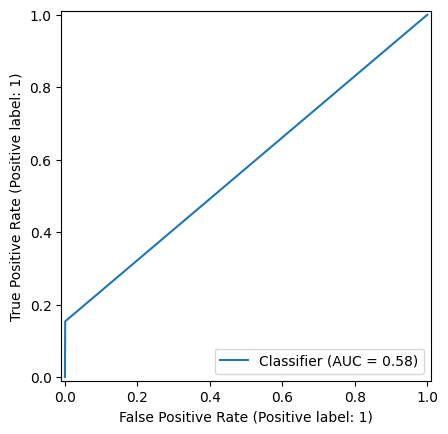

In [16]:
RocCurveDisplay.from_predictions(y_test, predictions)

In [17]:
auroc = roc_auc_score(y_test, predictions)
auprc = average_precision_score(y_test, predictions)
print('\nAUROC:', auroc, '\nAUPRC', auprc)


AUROC: 0.5764977260085724 
AUPRC 0.08157620721072498


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay

# Split the data into training and testing sets in 70:30 split
data_split = train_test_split(model_df_new1, test_size=0.3, random_state=42)

# Access the training data (the first element of the list)
train_data = data_split[0]

# Access the testing data (the second element of the list)
test_data = data_split[1]

# Generate embeddings
train_embeddings = generate_embeddings(train_data, api_key)
print(f' Train Data Embeddings Shape: {len(train_embeddings)} \n')

# Get the Lables for training from DOSAGE_MATCH1 column
train_labels = list(train_data['DOSAGE_MATCH1'])
print(f'Train Labels Shape: {len(train_labels)} \n')

# Fit the train data into Logistic Regression model
# this model uses the matching_text for the embeddings
model = LogisticRegression(max_iter=1000)
model.fit(train_embeddings, train_labels[:len(train_embeddings)])

Number of texts to embed: 5012
Generated 5012 embeddings.
Example Embedding (first 10 dimensions):
[0.054016177, -0.016128622, -0.04902074, 0.06730786, -0.026693704, -0.00942773, 0.012033623, 0.042782374, 0.006761547, -0.029495712]
... (Total dimensions: 768)
 Train Data Embeddings Shape: 5012 

Train Labels Shape: 5012 



LogisticRegression(max_iter=1000)

In [ ]:
# Generate embeddings for the test data
test_embeddings = generate_embeddings(test_data, api_key)
print(f' Test Data Embeddings Shape: {len(test_embeddings)} \n')
#print(test_embeddings)

# Get the test lables from DOSAGE_MATCH1 column, which contains the results
test_labels = list(test_data['DOSAGE_MATCH1'])
print(f'Test Labels Shape: {len(test_labels)} \n')

Number of texts to embed: 2149
Generated 2149 embeddings.
Example Embedding (first 10 dimensions):
[0.05626832, -0.026398227, -0.011750014, -0.0040910947, 0.010498313, -0.026024027, 0.019187685, 0.035740092, -0.026529158, -0.027994674]
... (Total dimensions: 768)
 Test Data Embeddings Shape: 2149 

Test Labels Shape: 2149 



In [ ]:
# Predict test probabilities using the generated embeddings
test_pred = model.predict_log_proba(test_embeddings)[:, 1]

# Calculate AUROC and AUPRC
auroc = roc_auc_score(test_labels[:len(test_embeddings)], test_pred, multi_class='ovr')
auprc = average_precision_score(test_labels[:len(test_embeddings)], test_pred)
print('\nAUROC:', auroc, '\nAUPRC', auprc)


AUROC: 0.8207572921541101 
AUPRC 0.23905175712095375


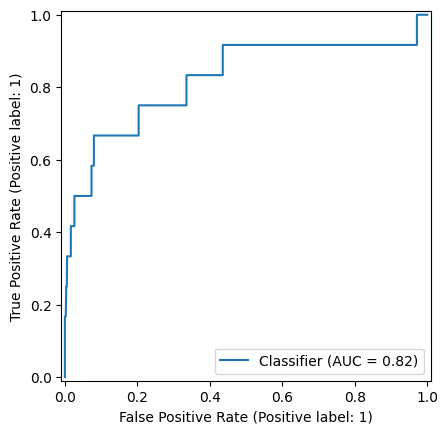

In [ ]:
# Plot the ROC Curve from test predictions
RocCurveDisplay.from_predictions(test_labels[:len(test_embeddings)], test_pred)

In [18]:
from tkinter import Y
# create a random forest classifier and fit the mode using 67:33 split
# this model uses the dosage amount for train/test predication
rfc = RandomForestClassifier(n_estimators=300, max_depth=None,
                             min_samples_split=2, min_samples_leaf=2,
                             random_state=42, n_jobs=-1)

# fit the model
rfc.fit(X_train, y_train)

# get the predictions
y_pred = rfc.predict(X_test)

# print the classification report for the best estimator
print(classification_report(y_test, y_pred))

# get the prediction probablities
y_pred_proba = rfc.predict_proba(X_test)

# create numerical lables using label_encoder
label_encoder = LabelEncoder()
numerical_labels = label_encoder.fit_transform(y_test)

# get the ROC AUC scores
roc_auc_scores = []
for i in range(y_pred_proba.shape[1]):
    roc_auc_scores.append(roc_auc_score(numerical_labels == i, y_pred_proba[:, i]))

# Calculate the average ROC AUC score
average_roc_auc_score = np.mean(roc_auc_scores)
print(f"Average ROC AUC Score: {average_roc_auc_score}")

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      2351
        True       1.00      0.38      0.56        13

    accuracy                           1.00      2364
   macro avg       1.00      0.69      0.78      2364
weighted avg       1.00      1.00      1.00      2364

Average ROC AUC Score: 0.9611376500997939


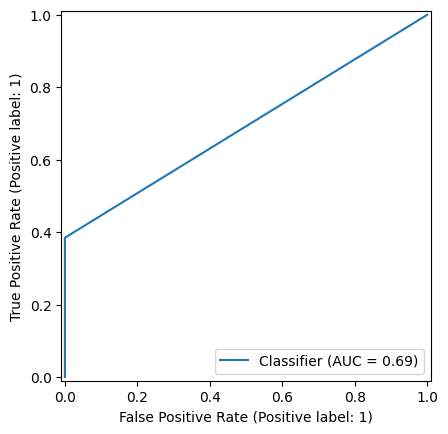

In [21]:
RocCurveDisplay.from_predictions(y_test, y_pred)

In [24]:
auroc = roc_auc_score(y_test, y_pred)
auprc = average_precision_score(y_test, y_pred)
print('\nAUROC:', auroc, '\nAUPRC:', auprc)


AUROC: 0.6923076923076923 
AUPRC: 0.38799947937003776


In [ ]:
# create a random forest classifier using the data from 70:30 split
# this model uses the matching_text for train/test predictions
rfc = RandomForestClassifier(n_estimators=300, max_depth=None,
                             min_samples_split=2, min_samples_leaf=2,
                             random_state=42, n_jobs=-1)

# train the classifier on the training data
rfc.fit(train_embeddings, train_labels[:len(train_embeddings)])

# print the classification report for the best estimator
y_pred = rfc.predict(train_embeddings)
print(classification_report(train_labels[:len(train_embeddings)], y_pred))

# print the ROC AUC score for the best estimator
y_pred_proba = rfc.predict_proba(train_embeddings)

# Convert string labels to numerical labels using LabelEncoder
label_encoder = LabelEncoder()
numerical_labels = label_encoder.fit_transform(train_labels[:len(train_embeddings)])

# Calculate ROC AUC score for each class and then average them
roc_auc_scores = []
for i in range(y_pred_proba.shape[1]):
    roc_auc_scores.append(roc_auc_score(numerical_labels == i, y_pred_proba[:, i]))

# Calculate the average ROC AUC score
average_roc_auc_score = np.mean(roc_auc_scores)
print(f"Average ROC AUC Score: {average_roc_auc_score}")

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      4970
        True       1.00      0.60      0.75        42

    accuracy                           1.00      5012
   macro avg       1.00      0.80      0.87      5012
weighted avg       1.00      1.00      1.00      5012

Average ROC AUC Score: 0.9998754431350004


In [ ]:
# define multiple classifiers (total 9, including LogisticRegression and RandomForestClassifier)
classifiers = {
    'AdaBoost': AdaBoostClassifier(algorithm='SAMME', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=300, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, n_jobs=-1,
                                              random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Neural Network': MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=None,
                                            min_samples_split=2, min_samples_leaf=2,
                                            random_state=42, n_jobs=-1)
}

# create a dictionary to store the statistics for each classifier
classifier_stats = {}

# Split the data into training and testing sets as 67:33
data_split = train_test_split(model_df_new1, test_size=0.33, random_state=42)

# Access the training data (the first element of the list)
train_data = data_split[0]

# Access the testing data (the second element of the list)
test_data = data_split[1]

embeddings = generate_embeddings(train_data, api_key)  # Generate embeddings
print(f' Embeddings Shape: {len(embeddings)} \n')

labels = list(train_data['DOSAGE_MATCH1'])
print(f' Labels Shape: {len(labels)} \n')

Number of texts to embed: 4797
Generated 4797 embeddings.
Example Embedding (first 10 dimensions):
[0.07391992, -0.019476332, -0.043732446, 0.027691618, 0.022824666, 0.03428562, 0.0055329506, 0.026753686, 0.01690187, -0.047831643]
... (Total dimensions: 768)
 Embeddings Shape: 4797 

 Labels Shape: 4797 



In [ ]:
# Generate embeddings for the test data
test_embeddings = generate_embeddings(test_data, api_key)
#print(test_embeddings)
print(f' Embeddings Shape: {np.shape(test_embeddings)} \n')

# Get the labels for the test data
test_labels = list(test_data.DOSAGE_MATCH1)
print(f' Labels Shape: {len(test_labels)} \n')

Number of texts to embed: 2364
Generated 2364 embeddings.
Example Embedding (first 10 dimensions):
[0.05626832, -0.026398227, -0.011750014, -0.0040910947, 0.010498313, -0.026024027, 0.019187685, 0.035740092, -0.026529158, -0.027994674]
... (Total dimensions: 768)
 Embeddings Shape: (2364, 768) 

 Labels Shape: 2364 



In [ ]:
# loop through the classifiers and train them
for name, clf in classifiers.items():
    print(f"Training {name}...")
    start_time = time.time() # start timer for training
    clf.fit(embeddings, labels[:len(embeddings)]) # train the classifier

    # calculate the classification report and ROC AUC score
    y_pred = clf.predict(test_embeddings)
    y_pred_proba = clf.predict_proba(test_embeddings)[:, 1]
    report = classification_report(test_labels[:len(test_embeddings)], y_pred, output_dict=True)
    roc_auc = roc_auc_score(test_labels[:len(test_embeddings)], y_pred_proba)

    end_time = time.time() # end the timer for the training
    runtime = end_time - start_time

    # store the statistics for the classifier
    classifier_stats[name] = {
        'report': report,
        'roc_auc': roc_auc,
        'runtime': runtime
    }

    # print the name of the classifier
    print(f"{name} Classifier:")
    print('-----------------------------------')

    #print the classification report
    print(f'Classification Report: \n{report}')

    # print the ROC AUC score for the best estimator
    print(f"ROC AUC Score: {roc_auc}")

    # print the runtime
    print(f"Runtime: {runtime} seconds")

    print('-----------------------------------')

Training AdaBoost...


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 0.9970276008492569, 'recall': 0.9987239472564866, 'f1-score': 0.9978750531236719, 'support': 2351.0}, 'True': {'precision': 0.6666666666666666, 'recall': 0.46153846153846156, 'f1-score': 0.5454545454545454, 'support': 13.0}, 'accuracy': 0.9957698815566836, 'macro avg': {'precision': 0.8318471337579618, 'recall': 0.7301312043974741, 'f1-score': 0.7716647992891086, 'support': 2364.0}, 'weighted avg': {'precision': 0.9952108952044287, 'recall': 0.9957698815566836, 'f1-score': 0.9953871230899582, 'support': 2364.0}}
ROC AUC Score: 0.8256061250531688
Runtime: 17.484439373016357 seconds
-----------------------------------
Training Gradient Boosting...
Gradient Boosting Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 0.9974500637484063, 'recall': 0.9982985963419821, 'f1-score': 0.997874149659864, 'support': 2351.0}, 'True': {'precision': 0.63

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 0.9945008460236887, 'recall': 1.0, 'f1-score': 0.9972428419936373, 'support': 2351.0}, 'True': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 13.0}, 'accuracy': 0.9945008460236887, 'macro avg': {'precision': 0.49725042301184436, 'recall': 0.5, 'f1-score': 0.49862142099681867, 'support': 2364.0}, 'weighted avg': {'precision': 0.9890319327418325, 'recall': 0.9945008460236887, 'f1-score': 0.99175885005374, 'support': 2364.0}}
ROC AUC Score: 0.8205673526813468
Runtime: 1.4682421684265137 seconds
-----------------------------------
Training K-Nearest Neighbors...
K-Nearest Neighbors Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 0.9961767204757859, 'recall': 0.9974478945129732, 'f1-score': 0.9968119022316685, 'support': 2351.0}, 'True': {'precision': 0.4, 'recall': 0.3076923076923077, 'f1-score': 0.347826086956521

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Neural Network Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 0.9945008460236887, 'recall': 1.0, 'f1-score': 0.9972428419936373, 'support': 2351.0}, 'True': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 13.0}, 'accuracy': 0.9945008460236887, 'macro avg': {'precision': 0.49725042301184436, 'recall': 0.5, 'f1-score': 0.49862142099681867, 'support': 2364.0}, 'weighted avg': {'precision': 0.9890319327418325, 'recall': 0.9945008460236887, 'f1-score': 0.99175885005374, 'support': 2364.0}}
ROC AUC Score: 0.773353401171351
Runtime: 11.858357906341553 seconds
-----------------------------------
Training Naive Bayes...
Naive Bayes Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 0.9978549978549979, 'recall': 0.9893662271373883, 'f1-score': 0.9935924818453652, 'support': 2351.0}, 'True': {'precision': 0.24242424242424243, 'recall': 0.6153846153846154, 'f1-score': 0.34782608695652173, 's

/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use

QDA Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 0.9945008460236887, 'recall': 1.0, 'f1-score': 0.9972428419936373, 'support': 2351.0}, 'True': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 13.0}, 'accuracy': 0.9945008460236887, 'macro avg': {'precision': 0.49725042301184436, 'recall': 0.5, 'f1-score': 0.49862142099681867, 'support': 2364.0}, 'weighted avg': {'precision': 0.9890319327418325, 'recall': 0.9945008460236887, 'f1-score': 0.99175885005374, 'support': 2364.0}}
ROC AUC Score: 0.5
Runtime: 1.0279004573822021 seconds
-----------------------------------
Training Random Forest...
Random Forest Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 0.9961864406779661, 'recall': 1.0, 'f1-score': 0.998089577584377, 'support': 2351.0}, 'True': {'precision': 1.0, 'recall': 0.3076923076923077, 'f1-score': 0.47058823529411764, 'support': 13.0}, 'accuracy': 0.9961928934010152, 'macr

                     Precision    Recall  Accuracy        F1   ROC AUC
Random Forest         0.996207  0.996193  0.996193  0.995189  0.961898
AdaBoost              0.995211  0.995770  0.995770  0.995387  0.825606
Gradient Boosting     0.995464  0.995770  0.995770  0.995595  0.877254
Decision Tree         0.994950  0.994924  0.994924  0.992755  0.538462
Logistic Regression   0.989032  0.994501  0.994501  0.991759  0.820567
QDA                   0.989032  0.994501  0.994501  0.991759  0.500000
Neural Network        0.989032  0.994501  0.994501  0.991759  0.773353
K-Nearest Neighbors   0.992898  0.993655  0.993655  0.993243  0.878873
Naive Bayes           0.993701  0.987310  0.987310  0.990041  0.829925


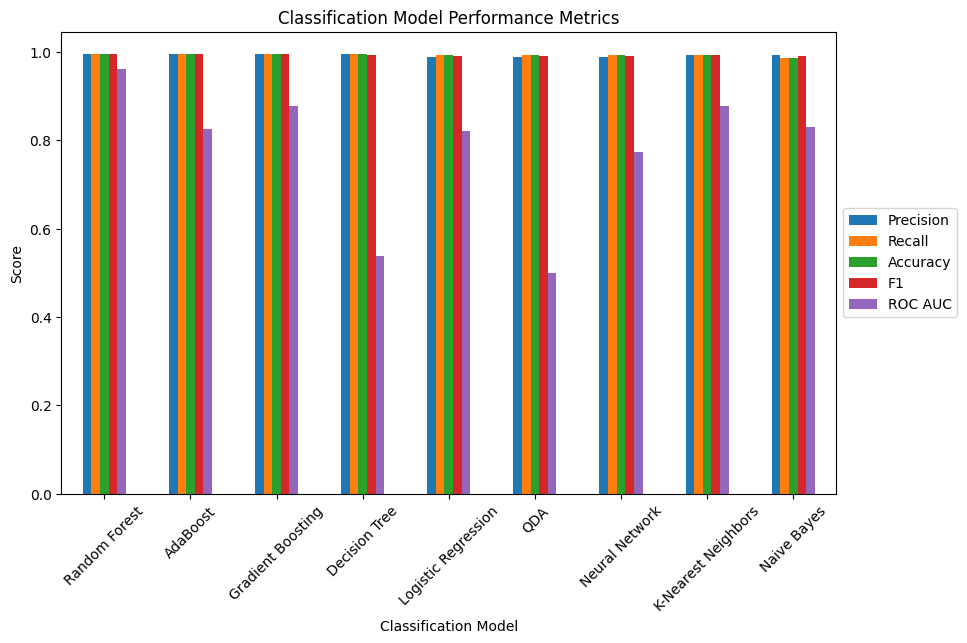

In [ ]:
# extract precision, recall and accuracy from the classification reports
precision = {name: report['weighted avg']['precision'] for name,
             report in [(name, classifier_stats[name]['report']) for name in classifier_stats.keys()]}
recall = {name: report['weighted avg']['recall'] for name,
             report in [(name, classifier_stats[name]['report']) for name in classifier_stats.keys()]}
accuracy = {name: report['accuracy'] for name,
            report in [(name, classifier_stats[name]['report']) for name in classifier_stats.keys()]}
f1_score = {name: report['weighted avg']['f1-score'] for name,
             report in [(name, classifier_stats[name]['report']) for name in classifier_stats.keys()]}
roc_auc = {name: report['roc_auc'] for name, report in classifier_stats.items()}
# runtime = {name: report['runtime'] for name, report in classifier_stats.items()}

# create a dataframe from the precision, recall and accuracy
stats_df = pd.DataFrame([precision, recall, accuracy, f1_score, roc_auc],
                        index=['Precision', 'Recall', 'Accuracy', 'F1', 'ROC AUC'])

# transpose the dataframe
stats_df = stats_df.T

# sort the dataframe by accuracy
stats_df = stats_df.sort_values(by='Accuracy', ascending=False)

# print the dataframe
print(stats_df)

# plot the statistics for each model using a bar plot with a bar for each metric
plt.figure(figsize=(10, 6))
stats_df.plot(kind='bar', ax=plt.gca())
plt.xlabel('Classification Model')
plt.ylabel('Score')
plt.title('Classification Model Performance Metrics')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.show()

In [ ]:
# define the classifiers (total 9, including LogisticRegression and RandomForestClassifier), this uses the 67:33 split data
classifiers = {
    'AdaBoost': AdaBoostClassifier(algorithm='SAMME', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=300, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, n_jobs=-1,
                                              random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Neural Network': MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=None,
                                            min_samples_split=2, min_samples_leaf=2,
                                            random_state=42, n_jobs=-1)
}

# create a dictionary to store the statistics for each classifier
classifier_stats_new = {}

# loop through the classifiers and train them
for name, clf in classifiers.items():
    print(f"Training {name}...")
    start_time = time.time() # start timer for training
    clf.fit(X_train, y_train) # train the classifier using the train data

    y_pred = clf.predict(X_train)
    y_pred_proba = clf.predict_proba(X_train)[:, 1]
    report = classification_report(y_train, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_train, y_pred_proba)

    end_time = time.time() # end the timer for the training
    runtime = end_time - start_time

    classifier_stats_new[name] = {
        'report': report,
        'roc_auc': roc_auc,
        'runtime': runtime
    }

    print(f"{name} Classifier:")
    print('-----------------------------------')
    print(f'Classification Report: \n{report}')
    print(f"ROC AUC Score: {roc_auc}")
    print(f"Runtime: {runtime} seconds")
    print('-----------------------------------')

Training AdaBoost...


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 0.9997897834769813, 'recall': 1.0, 'f1-score': 0.9998948806895827, 'support': 4756.0}, 'True': {'precision': 1.0, 'recall': 0.975609756097561, 'f1-score': 0.9876543209876543, 'support': 41.0}, 'accuracy': 0.9997915363769022, 'macro avg': {'precision': 0.9998948917384907, 'recall': 0.9878048780487805, 'f1-score': 0.9937746008386185, 'support': 4797.0}, 'weighted avg': {'precision': 0.9997915801994004, 'recall': 0.9997915363769022, 'f1-score': 0.9997902605211902, 'support': 4797.0}}
ROC AUC Score: 0.9999923075345135
Runtime: 17.356083869934082 seconds
-----------------------------------
Training Gradient Boosting...
Gradient Boosting Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 4756.0}, 'True': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 41.0}, 'accuracy': 1.0, 'macro a

/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


QDA Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 0.9922804089296892, 'recall': 1.0, 'f1-score': 0.9961252487171431, 'support': 4756.0}, 'True': {'precision': 1.0, 'recall': 0.0975609756097561, 'f1-score': 0.17777777777777778, 'support': 41.0}, 'accuracy': 0.9922868459453825, 'macro avg': {'precision': 0.9961402044648446, 'recall': 0.5487804878048781, 'f1-score': 0.5869515132474604, 'support': 4797.0}, 'weighted avg': {'precision': 0.9923463883405466, 'recall': 0.9922868459453825, 'f1-score': 0.9891308258886016, 'support': 4797.0}}
ROC AUC Score: 0.5487804878048781
Runtime: 0.7484042644500732 seconds
-----------------------------------
Training Random Forest...
Random Forest Classifier:
-----------------------------------
Classification Report: 
{'False': {'precision': 0.9972740616481442, 'recall': 1.0, 'f1-score': 0.9986351706036746, 'support': 4756.0}, 'True': {'precision': 1.0, 'recall': 0.6829268292682927, 'f1-score': 0.811594202898

                     Precision    Recall  Accuracy        F1   ROC AUC
Gradient Boosting     1.000000  1.000000  1.000000  1.000000  1.000000
AdaBoost              0.999792  0.999792  0.999792  0.999790  0.999992
Random Forest         0.997297  0.997290  0.997290  0.997037  0.999990
K-Nearest Neighbors   0.994489  0.994997  0.994997  0.994571  0.997559
Decision Tree         0.995022  0.994997  0.994997  0.993968  0.707379
Logistic Regression   0.992552  0.992495  0.992495  0.989573  0.940158
Neural Network        0.992346  0.992287  0.992287  0.989131  0.859038
QDA                   0.992346  0.992287  0.992287  0.989131  0.548780
Naive Bayes           0.993172  0.986658  0.986658  0.989150  0.989320


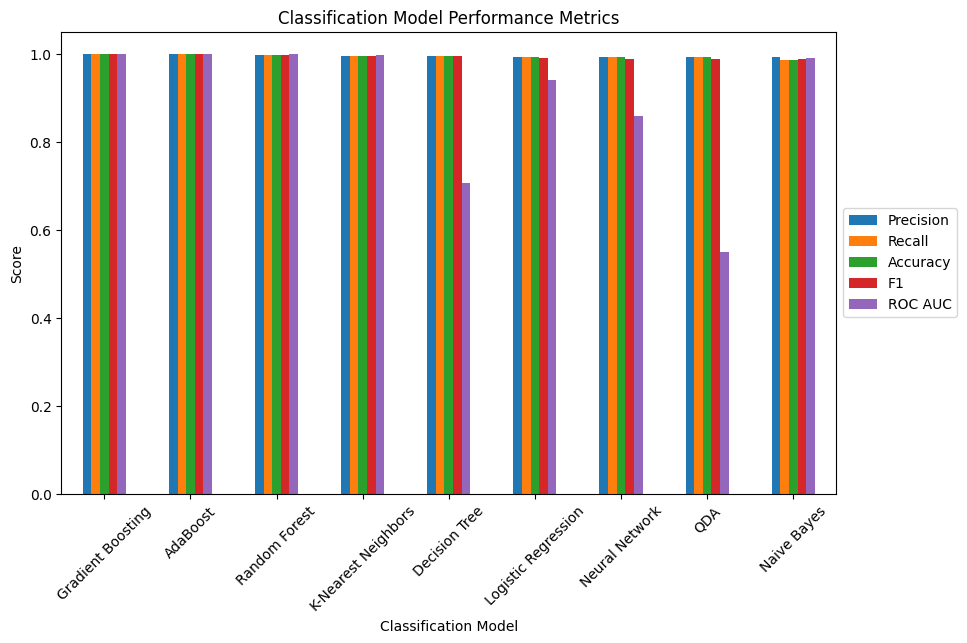

In [ ]:
# extract precision, recall and accuracy from the new classification reports
precision = {name: report['weighted avg']['precision'] for name,
             report in [(name, classifier_stats_new[name]['report']) for name in classifier_stats_new.keys()]}
recall = {name: report['weighted avg']['recall'] for name,
             report in [(name, classifier_stats_new[name]['report']) for name in classifier_stats_new.keys()]}
accuracy = {name: report['accuracy'] for name,
            report in [(name, classifier_stats_new[name]['report']) for name in classifier_stats_new.keys()]}
f1_score = {name: report['weighted avg']['f1-score'] for name,
             report in [(name, classifier_stats_new[name]['report']) for name in classifier_stats_new.keys()]}
roc_auc = {name: report['roc_auc'] for name, report in classifier_stats_new.items()}
#runtime = {name: report['runtime'] for name, report in classifier_stats_new.items()}

# create a dataframe from the precision, recall and accuracy
stats_df = pd.DataFrame([precision, recall, accuracy, f1_score, roc_auc],
                        index=['Precision', 'Recall', 'Accuracy', 'F1', 'ROC AUC'])

# transpose the dataframe
stats_df = stats_df.T

# sort the dataframe by accuracy
stats_df = stats_df.sort_values(by='Accuracy', ascending=False)

# print the dataframe
print(stats_df)

# plot the statistics for each model using a bar plot with a bar for each metric
plt.figure(figsize=(10, 6))
stats_df.plot(kind='bar', ax=plt.gca())
plt.xlabel('Classification Model')
plt.ylabel('Score')
plt.title('Classification Model Performance Metrics')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.show()